### Performance evaluation on the HSDM data set ###

In [1]:
import sys
import os
import numpy as np
import json
import pandas as pd
import logging
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

logger = logging.getLogger(__name__)

# PyTorch
import torch
from torchvision import ops

%load_ext autoreload
%autoreload 2
import computervision
from computervision.imageproc import is_image, ImageData, clipxywh, xyxy2xywh, xywh2xyxy, plot_boxes
from computervision.datasets import DETRdataset, get_gpu_info
from computervision.transformations import AugmentationTransform
from computervision.performance import DetectionMetrics
from computervision.inference import DETRInference

print(f'Project version: {computervision.__version__}')
print(f'Authors: {computervision.__authors__}')
print(f'Python version:  {sys.version}')

Project version: v0.0.2
Authors: The Core for Computational Biomedicine at Harvard Medical School
https://dbmi.hms.harvard.edu/about-dbmi/core-computational-biomedicine
Python version:  3.12.3 (main, Jun 18 2025, 17:59:45) [GCC 13.3.0]


In [2]:
# Check GPU availability
device, device_str = get_gpu_info()
print(f'Current device {device}')

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.8.0a0+34c6371d24.nv25.08
CUDA version:      13.0
CUDNN version:     91200
Device for model training/inference: cuda:0
Current device cuda:0


In [15]:
# Dataset and image files
dataset_name = 'dataset_object_240921'
image_dir = os.path.join(os.environ.get('DATA'), dataset_name)
df_file_name = 'objectdata_240921_clean_ide_dset.parquet'
df_file = os.path.join(image_dir, df_file_name)
df = pd.read_parquet(df_file)
display(df.head(2))

pos_col = 'pos'
bbox_col = 'bbox'
dset_col = 'dset'
file_col = 'file_name'

# Filter the test data
df = df.loc[(~df[pos_col].isnull()) & (df[dset_col].isin(['val', 'test']))]
n_images = len(df[file_col].unique())
n_annotations = df.shape[0]
print(f'Images:      {n_images}')
print(f'Annotations: {n_annotations}')

# Model checkpoint
model_name = 'rtdetr_dtx_251012_02'
checkpoint = 'checkpoint-14850'
batch_size = 8
model_dir = os.path.join(os.environ.get('DATA'), 'model', model_name)
checkpoint_dir = os.path.join(model_dir, checkpoint)
detr = DETRInference(device=device, checkpoint_path=checkpoint_dir, batch_size=batch_size)

# Load the model configuration
config_file_name = f'{model_name}.json'
config_file = os.path.join(model_dir, config_file_name)
with open(config_file, mode='r') as fl:
    config = json.load(fl)
print(list(config.keys()))
model_info = config.get('model_info')

,file_name,width,height,bbox,pos,disease,dset
0,0060bce2_20210430_02.png,1200,854,"[204, 0, 620, 443]",14,unstable,val
1,0060bce2_20210430_02.png,1200,854,"[715, 409, 485, 445]",18,stable,val


Images:      639
Annotations: 1129
['model_info', 'id2label', 'training_args', 'processor_params', 'bbox_format']


### Run predictions on the data set for a given threshold value ###

In [20]:
# Set the prediction threshold
thr = 0.05

# Create a data set with the test data
bbox_format = {'format': 'coco',
               'label_fields': ['tooth_position'],
               'clip': True,
               'min_area': 10000}

im_width = model_info.get('im_width')
im_height = model_info.get('im_height')

val_transforms = AugmentationTransform(im_width=im_width, 
                                       im_height=im_height).\
    get_transforms(name='val')

dataset = DETRdataset(data=df.copy(), 
                      image_processor=detr.processor,
                      image_dir=image_dir,
                      file_name_col=file_col,
                      label_id_col=None,
                      bbox_col=None,
                      bbox_format=bbox_format,
                      transforms=val_transforms)

# Run the predictions on the data set
pred_df = detr.predict_on_dataset(dataset, threshold=0.05)

Predicting batch 10 of 80.
Predicting batch 20 of 80.
Predicting batch 30 of 80.
Predicting batch 40 of 80.
Predicting batch 50 of 80.
Predicting batch 60 of 80.
Predicting batch 70 of 80.
Predicting batch 80 of 80.


In [135]:
# Add the file names to the data frame
file_list = list(df[file_col].unique())
file2id = dict(zip(file_list, range(len(file_list))))
id2file = {int(image_id): file for file, image_id in file2id.items()}
pred_df[file_col] = pred_df['image_id'].apply(lambda image_id: id2file.get(image_id))

# Add the labels to the data frame
id2label = config.get('id2label')
id2label = {int(category_id): int(label) for category_id, label in id2label.items()}
pred_df[pos_col] = pred_df['category_id'].apply(lambda category_id: id2label.get(category_id))

# Find the images with no predictions
pred_df_empty = pred_df.loc[pred_df[pos_col].isnull(), file_col].unique()

# Keep a data frame with the images that had predicted bounding boxes
predicted_df = pred_df.loc[~pred_df[pos_col].isnull()]

print(f'Images in data set:         {len(dataset)}')
print(f'Images without predictions: {len(pred_df_empty)}')
print(f'Images with predictions:    {len(predicted_df[file_col].unique())}')

display(pred_df.head(5))

Images in data set:         639
Images without predictions: 103
Images with predictions:    536


,image_id,image_width,image_height,batch,category_id,bbox,score,area,file_name,pos
0,0,1200,854,0,18,"[342, 325, 527, 279]",0.092713,147033,0060bce2_20210430_02.png,19.0
1,0,1200,854,0,12,"[195, 0, 444, 315]",0.080715,139860,0060bce2_20210430_02.png,13.0
2,0,1200,854,0,14,"[596, 0, 363, 296]",0.050504,107448,0060bce2_20210430_02.png,15.0
3,1,854,1200,0,NaN,NaN,NaN,NaN,0060bce2_20210430_05.png,NaN
4,2,1200,854,0,18,"[549, 0, 459, 477]",0.062371,218943,0063ddfd_20210226_00.png,19.0


### Classify the detections: TP, FP, FN for all images ###

No predictions for image: 0060bce2_20210430_05.png
No predictions for image: 00781f17_20230509_16.png
No predictions for image: 012447b4_20210112_07.png
No predictions for image: 026f886d_20210823_00.png
No predictions for image: 04608d05_20220718_05.png
No predictions for image: 0476a9f2_20230502_01.png
No predictions for image: 094d2c71_20230208_01.png


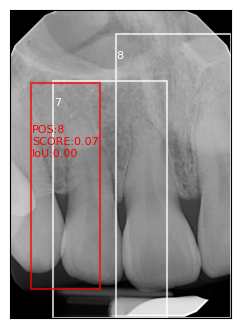

In [205]:
# Classify predictions for all images
iou_threshold = 0.5
pred_file_df_list = []
missed_file_df_list = []

for file_idx, file_name in enumerate((file_list[:53])):
    # file_idx = 1
    # file_name = file_list[file_idx]
    file = os.path.join(image_dir, file_name)
    im = ImageData().load_image(file)
    im = ImageData().np2color(im)
    
    im_height, im_width = im.shape[:2]
    
    file_df = df.loc[df[file_col] == file_name]
    bboxes = file_df[bbox_col].tolist()
    bboxes = [clipxywh(list(bbox), xlim=(0, im_width), ylim=(0, im_height)) for bbox in bboxes]
    labels = file_df[pos_col].tolist()
    
    file_pred_df = predicted_df.loc[predicted_df[file_col] == file_name]
    
    if len(file_pred_df) > 0:

        # Detections for this image
        file_pred_df = file_pred_df.astype({pos_col: int}) 
        pred_bboxes = file_pred_df[bbox_col].tolist()
        pred_bboxes = [clipxywh(list(bbox), xlim=(0, im_width), ylim=(0, im_height)) for bbox in pred_bboxes]
        pred_labels = file_pred_df[pos_col].tolist()
        pred_scores = file_pred_df['score'].tolist()
        
        # Classify predictions based on IoU
        dm = DetectionMetrics(im_width=im_width, im_height=im_height, bbox_format='xywh')
        pred_cl = dm.classify_predictions(true_labels=labels, 
                                          true_bboxes=bboxes, 
                                          pred_labels=pred_labels, 
                                          pred_bboxes=pred_bboxes, 
                                          iou_threshold=iou_threshold)
        
        # Keep only those predicted classes that we have in the ground truth data
        # With this, we remove predictions that are correct
        true_pred_cl = pred_cl.loc[pred_cl['pred_label'].isin(labels)]
        
        if len(true_pred_cl) > 0:
            
            true_pred_cl.insert(loc=0, column=file_col, value=file_name)
            pred_file_df_list.append(true_pred_cl)

        # False Negatives: Labels in the ground truth data that were not detected
        # We can determine the false negatives for those objects that were labeled
        missed = sorted(list(set(labels).difference(pred_labels)))
        missed_file_df = pd.DataFrame({pos_col: missed})
        
    else:
        
        print(f'No predictions for image: {file_name}')
        missed_file_df = pd.DataFrame({pos_col: sorted(labels)})
    
    missed_file_df.insert(loc=0, column=file_col, value=file_name)
    missed_file_df_list.append(missed_file_df)

missed_predictions = pd.concat(missed_file_df_list, axis=0, ignore_index=True)
matched_predictions = pd.concat(pred_file_df_list, axis=0, ignore_index=True)
                
# Show the results for the last image
pred_labscores = [f'POS:{label}\nSCORE:{score:.2f}\nIoU:{iou:.2f}' \
                          for label, score, iou in zip(pred_labels_cl, pred_scores_cl, iou_list)]
fig, ax = plt.subplots(figsize=(4, 4))
ax = plot_boxes(image=im, box_list=bboxes, label_list=labels, ax=ax, color='w')
#ax = plot_boxes(image=im, box_list=pred_bboxes, 
#                label_list=pred_labels, ax=ax, color='r', offset_xy=(0, 100))
ax = plot_boxes(image=im, box_list=pred_bboxes_cl, 
                label_list=pred_labscores, ax=ax, color='r', offset_xy=(0, 200))

plt.show()

### Recall ###

Note: We do not know the false positive predictions because we do not have a completely labled test set.
Therefore, we cannot calculate precision values. But we can calculate the recall.

In [212]:
pos_list = list(id2label.values())
pos = 19
matched_pos = matched_predictions.loc[matched_predictions['pred_label'] == pos]
missed_pos = missed_predictions.loc[missed_predictions[pos_col] == pos]

In [213]:
display(matched_pos)
display(missed_pos)

,file_name,pred_label,TP,IoU,FN,duplicate_TP
0,0060bce2_20210430_02.png,19,0,0.165620,2,False
4,0063ddfd_20210226_12.png,19,0,0.259769,1,False
5,00781f17_20230509_00.png,19,0,0.477585,1,False
25,04608d05_20220718_07.png,19,0,0.065150,1,False


,file_name,pos
17,012447b4_20210112_12.png,19.0
33,04622ad7_20130226_01.png,19.0
